In [1]:
# Euskera v1.0

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
cd ..

/Users/armandoroqueestrada/Euskera_data/Euskera_github


Euskera v1.0

# Background configuration

In this notebook, we show an illustrative example of how create the background profile. For more details, see the documentation.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

import background as bg  # importing background package

In [5]:
bg.general()  # call the global general plot configurations

## Without self-interaction ($\lambda_n = \lambda_s = 0$)

First, we consider the case without a self-interaction term. In this situation, there is a scaling freedom, which means we can fix the central amplitude to $\sigma_0 = 1$ and derive the rest from:

\begin{align}
t \to \lambda_*^{-1} t, \quad \vec{x}\to \lambda_*^{-1/2} \vec{x},\quad U\to \lambda_x U, \quad \vec\psi \to \lambda_* \vec\psi
\end{align}

#### Constant polarization with $n = 0, 1$ 

#### Linear polarization

Finding a profile with nodes: [0]
Final precision: U0 = [0.91857977] radius 22.334941560748167


/Users/armandoroqueestrada/Euskera_data/Euskera_github/background/Plot/plot_conf.py:345: UserWarning: The py, pz ccomponents was off because the number of fields is 1
  warnings.warn("The py, pz ccomponents was off because the number of fields is %d"%numFields)


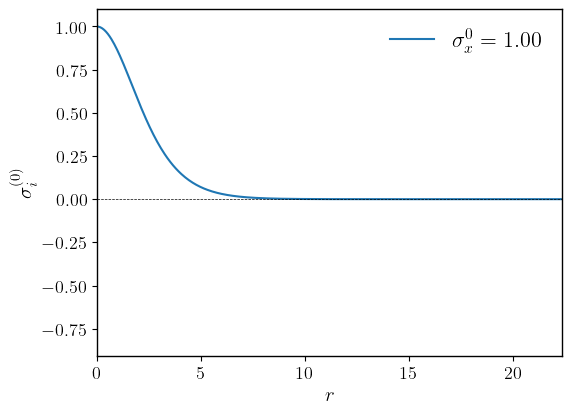

Finding a profile with nodes: [1]
Final precision: U0 = [1.209959] radius 30.286693117848095


/Users/armandoroqueestrada/Euskera_data/Euskera_github/background/Plot/plot_conf.py:345: UserWarning: The py, pz ccomponents was off because the number of fields is 1
  warnings.warn("The py, pz ccomponents was off because the number of fields is %d"%numFields)


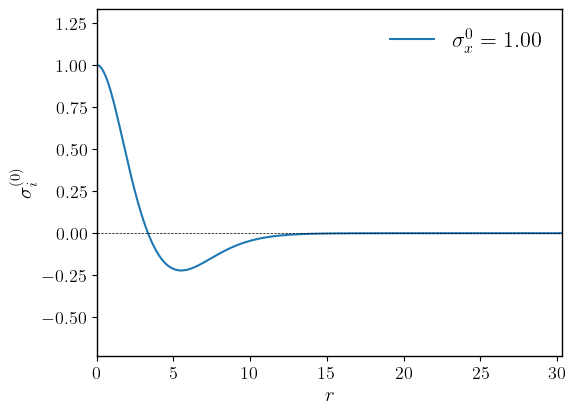

In [ ]:
LambT = 0 # autointeracción: 1 (repulsive), 0 (without selinteraction), -1 (attractive)
nodosval = [0, 1]

p1x, u1x = 0, 0  # the first derivative value for the field (p1x) and the effective potential (u1x). Both are zero.
rmax = 1000  # iteration radius

# Range of values used as seed for the effective potential
Uxint = [0.00000012057279119421096, 18]
numFields = 1

# Method
met = 'DOP853'
gamma = 0 # 1 radial
Rtol = 1e-13 
Atol = 1e-15

# boundary conditions list
p0x = 1.0  # central amplitude of the field
Ini0 = [p0x, p1x, u1x]  

datos = []
for nodo in nodosval:  # The central amplitude of \sigma_x (p0x) and
    nodos = [nodo] 
    u0Val, rTmax, events = bg.MultFreq_solveG2(Ini0, numFields=numFields, Uintrs=[Uxint], rmax=rmax, LambT=LambT, gamma=gamma, met=met,
                                                nodos=nodos, lim=1e-14, info=False, klim=5000, outval=0, delta=0., Rtol=Rtol, Atol=Atol)

    # plot the result
    U0 = np.zeros(4*numFields)
    U0[:2*numFields] = Ini0[:2*numFields]
    U0[2*numFields+1::2] = Ini0[2*numFields:]
    U0[2*numFields::2] = u0Val
    arg = [numFields, LambT, gamma]

    bg.plotPerf(U0, rTmax, arg=arg)
    
    # Save the results in a list
    datos.append([p0x, rTmax, gamma, LambT, nodos[0], numFields, met, Rtol, Atol, u0Val[0]])  # [f0, rmax, gamma, LambT, nodes, _, met, Rtol, Atol, u0]

In [7]:
# Extending the solutions
Ext = 100
Np = 200
rtake = -160

data, dataEx = [], []
for dataPerf in datos:
    en, Mas, rD, sD, dsD, uD, duD, LamV, gamma = bg.profilesFromSolut(dataPerf, info=True)  # Solving
    rDnew, sDnew, dsDnew, uDnew, duDnew = bg.extend(gamma, rD[:rtake],
                                                                sD[0][:rtake], dsD[0][:rtake],
                                                                uD[0][:rtake], duD[0][:rtake],
                                                                Ext, Np, inf=False)
    data.append([en[0], Mas[0], rD, sD[0], dsD[0], uD[0], duD[0], LamV])
    dataEx.append([en[0], Mas[0], rDnew, sDnew, dsDnew, uDnew, duDnew, LamV])

Mass values: [43.58339244901069]
Eigenvalues of energy: [-0.9789591957601331]
Mass values: [96.93636878343519]
Eigenvalues of energy: [-0.9162746282239667]


/Users/armandoroqueestrada/Euskera_data/Euskera_github/background/Background/background.py:292: UserWarning: En and Mas are not provided. We computed them from the field profile.
 IMPORTANT: for multifrequency, this procedure is not correct.
  warnings.warn("En and Mas are not provided. We computed them from the field profile.\n IMPORTANT: for multifrequency, this procedure is not correct.")


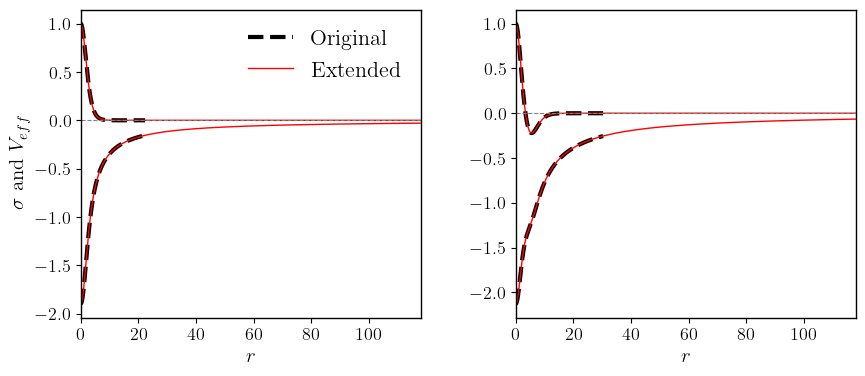

In [13]:
# show profiles
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.28))

for i, axes in enumerate(ax):
    # original
    axes.plot(data[i][2], data[i][3], ls='--', c='k', lw=3)
    axes.plot(data[i][2], data[i][0] - data[i][5], ls='--', lw=3, c='k')

    # extension
    axes.plot(dataEx[i][2], dataEx[i][3], ls='-', c='r', lw=1)
    axes.plot(dataEx[i][2], dataEx[i][0] - dataEx[i][5], ls='-', lw=1, c='r')
    
    axes.hlines(y=0, xmin=0, xmax=118, ls='--', lw=0.8, color='gray')
    axes.set_xlim(0, 118)

ax[0].plot([],[], ls='--', c='k', lw=3, label='Original')
ax[0].plot([],[], ls='-', c='r', lw=1, label='Extended')
ax[0].set_ylabel(r'$\sigma$ and $V_{eff}$')

ax[0].set_xlabel(r'$r$')
ax[1].set_xlabel(r'$r$')
ax[0].legend(loc='upper right', frameon=False)

In [ ]:
# saving if needed
np.savez(f"profiles/profiles_const_lam_0_n_0_1.npz", np.array(dataEx, dtype=object))

####  Radial polarization

Finding a profile with nodes: [0]
Final precision: U0 = [1.69471091] radius 17.762393210062694


/Users/armandoroqueestrada/Euskera_data/Euskera_github/background/Plot/plot_conf.py:345: UserWarning: The py, pz ccomponents was off because the number of fields is 1
  warnings.warn("The py, pz ccomponents was off because the number of fields is %d"%numFields)


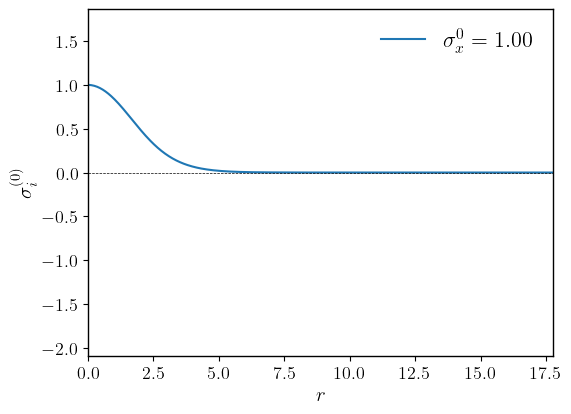

Finding a profile with nodes: [1]
Final precision: U0 = [2.06157859] radius 22.540060832468846


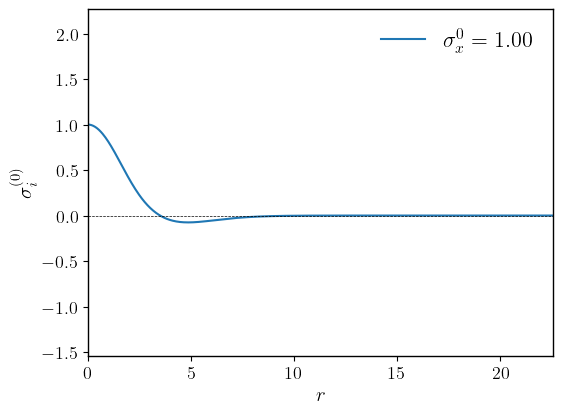

In [28]:
LambT = 0 # autointeracción: 1 (repulsive), 0 (without selinteraction), -1 (attractive)
nodosval = [0, 1]

p1x, u1x = 0, 0  # the first derivative value for the field (p1x) and the effective potential (u1x). Both are zero.
rmax = 1000  # iteration radius

# Range of values used as seed for the effective potential
Uxint = [0.00000012057279119421096, 18]
numFields = 1

# Method
met = 'DOP853'
gamma = 1 # 0 linear
Rtol = 1e-13 
Atol = 1e-15

# boundary conditions list
p0x = 1.0  # central amplitude of the field
Ini0 = [p0x, p1x, u1x]  

datos = []
for nodo in nodosval:  # The central amplitude of \sigma_x (p0x) and
    nodos = [nodo] 
    u0Val, rTmax, events = bg.MultFreq_solveG2(Ini0, numFields=numFields, Uintrs=[Uxint], rmax=rmax, LambT=LambT, gamma=gamma, met=met,
                                                nodos=nodos, lim=1e-14, info=False, klim=5000, outval=0, delta=0., Rtol=Rtol, Atol=Atol)

    # plot the result
    U0 = np.zeros(4*numFields)
    U0[:2*numFields] = Ini0[:2*numFields]
    U0[2*numFields+1::2] = Ini0[2*numFields:]
    U0[2*numFields::2] = u0Val
    arg = [numFields, LambT, gamma]

    bg.plotPerf(U0, rTmax, arg=arg)
    
    # Save the results in a list
    datos.append([p0x, rTmax, gamma, LambT, nodos[0], numFields, met, Rtol, Atol, u0Val[0]])  # [f0, rmax, gamma, LambT, nodes, _, met, Rtol, Atol, u0]

In [29]:
# Extending the solutions
Ext = 100
Np = 200
rtake = -160

data, dataEx = [], []
for dataPerf in datos:
    en, Mas, rD, sD, dsD, uD, duD, LamV, gamma = bg.profilesFromSolut(dataPerf, info=True)  # Solving
    rDnew, sDnew, dsDnew, uDnew, duDnew = bg.extend(gamma, rD[:rtake],
                                                                sD[0][:rtake], dsD[0][:rtake],
                                                                uD[0][:rtake], duD[0][:rtake],
                                                                Ext, Np, inf=False)
    
    data.append([en[0], Mas[0], rD,
                 rD**gamma * sD[0],
                 rD**(gamma-1) * (gamma * sD[0] + rD*dsD[0]),
                 uD[0], duD[0], LamV])
    dataEx.append([en[0], Mas[0], rDnew,
                   rDnew**gamma * sDnew,
                   rDnew**(gamma-1) * (gamma * sDnew + rDnew * dsDnew),
                   uDnew, duDnew, LamV])

Mass values: [119.18637009043606]
Eigenvalues of energy: [-2.4336505407338915]
Mass values: [193.33080149446695]
Eigenvalues of energy: [-2.082480506150805]


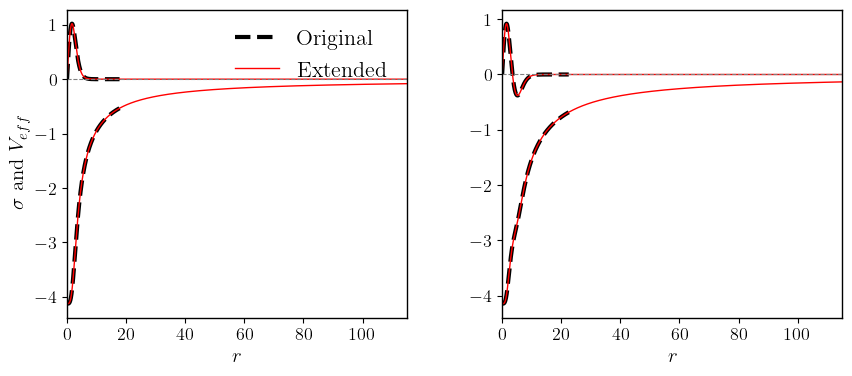

In [30]:
# show profiles
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.28))

for i, axes in enumerate(ax):
    # original
    axes.plot(data[i][2], data[i][3], ls='--', c='k', lw=3)
    axes.plot(data[i][2], data[i][0] - data[i][5], ls='--', lw=3, c='k')

    # extension
    axes.plot(dataEx[i][2], dataEx[i][3], ls='-', c='r', lw=1)
    axes.plot(dataEx[i][2], dataEx[i][0] - dataEx[i][5], ls='-', lw=1, c='r')
    
    axes.hlines(y=0, xmin=0, xmax=118, ls='--', lw=0.8, color='gray')
    axes.set_xlim(0, 115)

ax[0].plot([],[], ls='--', c='k', lw=3, label='Original')
ax[0].plot([],[], ls='-', c='r', lw=1, label='Extended')
ax[0].set_ylabel(r'$\sigma$ and $V_{eff}$')

ax[0].set_xlabel(r'$r$')
ax[1].set_xlabel(r'$r$')
ax[0].legend(loc='upper right', frameon=False)

In [ ]:
# saving if needed
np.savez("profiles/profiles_crad_lam_0_n_0_1.npz", np.array(dataEx, dtype=object))

#### Multifrequency with a zero z-component

## With self-interaction